<a href="https://colab.research.google.com/github/NeevWadhwa-Helloworld/Machine-Learning-Projects/blob/main/Youtube_Trending_Video_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Youtube Trending Video Analysis**

In [10]:
import pandas as pd
import numpy as np
import matplotlib as mpl
from matplotlib import pyplot as plt
import seaborn as sns
import warnings
from collections import Counter
import datetime
import wordcloud
import json

In [11]:
df=pd.read_csv("/content/Requirments (3).zip")
PLOT_COLORS=["#268bd2","#0052CC","#FF5722","#b58900","#003f5c"]
pd.options.display.float_format='{:.2f}'.format
sns.set(style="ticks")
plt.rc('figure',figsize=(8,5),dpi=100)
plt.rc('axes',labelpad=20,facecolor="#ffffff",linewidth=0.4,grid=True,labelsize=14)
plt.rc('patch',linewidth=0)
plt.rc('xtick.major',width=0.2)
plt.rc('ytick.major',width=0.2)
plt.rc('grid',color='#9E9E9E',linewidth=0.4)
plt.rc('font',family='sans-serif',weight='normal')
plt.rc('text',color='#282828')
plt.rc('savefig',pad_inches=0.3,dpi=300)

In [12]:
df["description"]=df["description"].fillna(value="")

In [13]:
df.describe()

,category_id,views,likes,dislikes,comment_count
count,35349.00,35349.00,35349.00,35349.00,35349.00
mean,20.10,1902529.32,61493.63,3097.44,7066.05
std,7.52,5839415.14,181625.60,29569.72,30680.32
min,1.00,549.00,0.00,0.00,0.00
25%,17.00,201980.00,4485.00,170.00,526.00
50%,24.00,561752.00,15163.00,531.00,1589.00
75%,25.00,1501028.00,45309.00,1602.00,4692.00
max,43.00,149376127.00,3749810.00,1674420.00,1361580.00


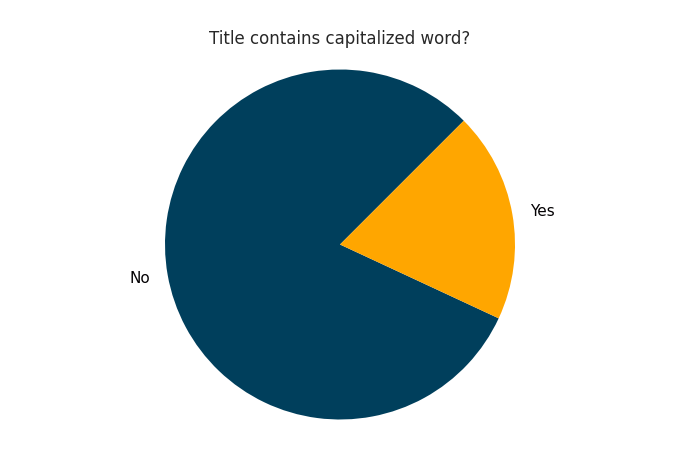

In [14]:
def contains_capitalized_word(s):
  for w in s.split():
    if w.isupper():
      return True
    return False
df["contains_capitalized"]=df["title"].apply(contains_capitalized_word)
value_counts=df["contains_capitalized"].value_counts().to_dict()
fig,ax=plt.subplots()
_=ax.pie([value_counts[False],value_counts[True]],labels=['No','Yes'],colors=['#003f5c','#ffa600'],textprops={'color':'#040204'},startangle=45)
_=ax.axis('equal')
_=ax.set_title('Title contains capitalized word?')

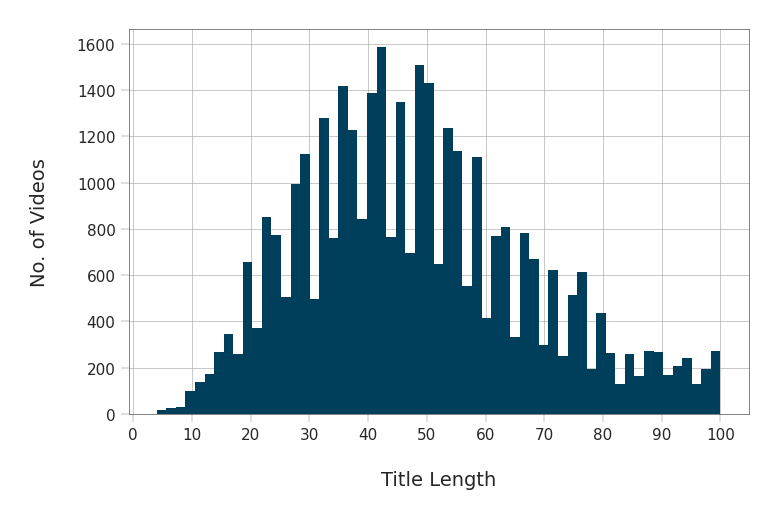

In [19]:
df["title_length"] = df["title"].apply(lambda x: len(x))
fig, ax = plt.subplots()

# Removed 'rug=False' entirely
_ = sns.histplot(
    df["title_length"],
    kde=False,
    color=PLOT_COLORS[4],
    alpha=1,
    ax=ax,
)

_ = ax.set(xlabel="Title Length", ylabel="No. of Videos", xticks=range(0, 110, 10))

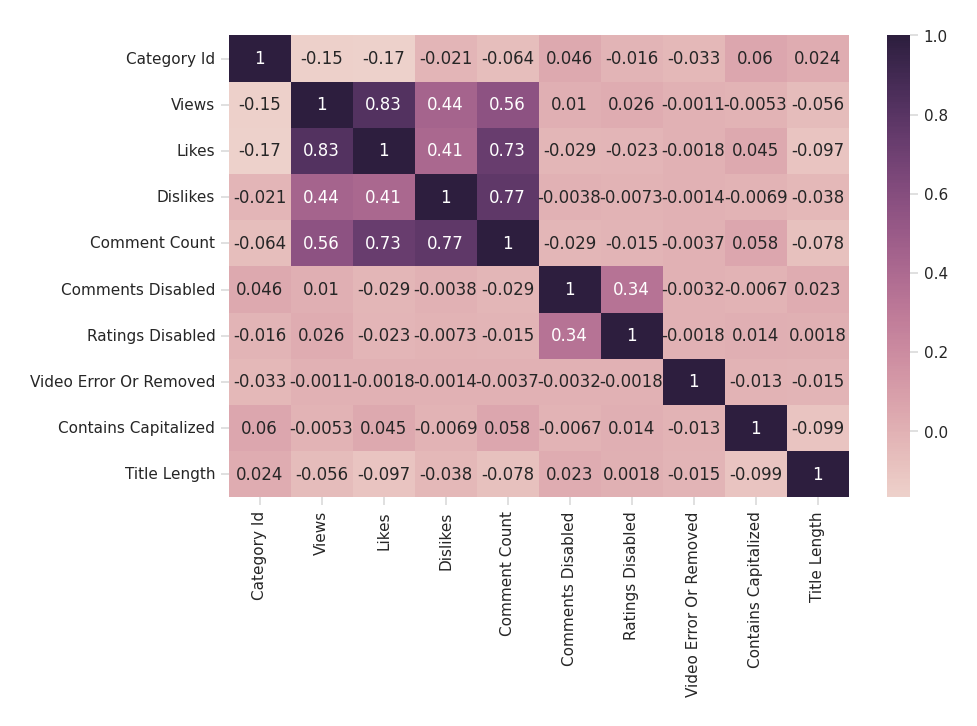

In [21]:
h_labels = [
    x.replace("_", " ").title()
    for x in list(df.select_dtypes(include=["number", "bool"]).columns.values)
]
fig, ax = plt.subplots(figsize=(10, 6))

# Fixed: added numeric_only=True inside df.corr()
_ = sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    xticklabels=h_labels,
    yticklabels=h_labels,
    cmap=sns.cubehelix_palette(as_cmap=True),
    ax=ax,
)

(np.float64(-0.5), np.float64(1199.5), np.float64(499.5), np.float64(-0.5))

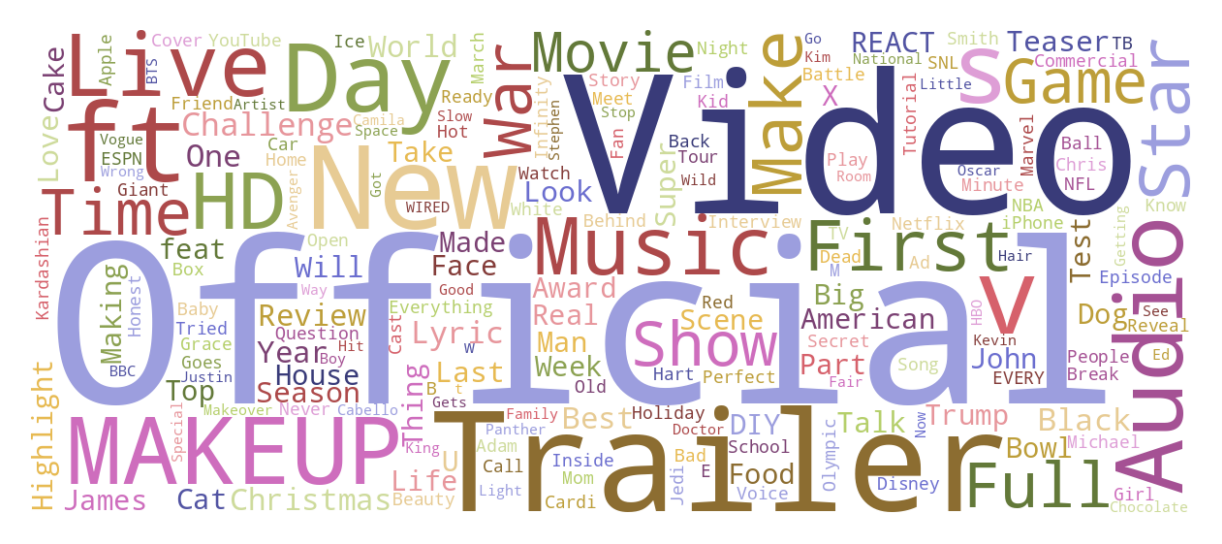

In [22]:
title_words=list(df["title"].apply(lambda x:x.split()))
title_words=[x for y in title_words for x in y]
wc=wordcloud.WordCloud(width=1200,height=500,collocations=False,background_color="white",colormap="tab20b").generate(" ".join(title_words))
plt.figure(figsize=(15,10))
plt.imshow(wc,interpolation="bilinear")
plt.axis("off")